In [143]:
import zarr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [144]:
vol = zarr.open(
    "/hpcstor6/scratch01/a/a.kanamarlapudi001/cell_tracking/biohub-cell-tracking-during-development/train/44b6_0113de3b.zarr",
    mode="r",
)["0"]


In [145]:
print(vol.shape)

(100, 64, 256, 256)


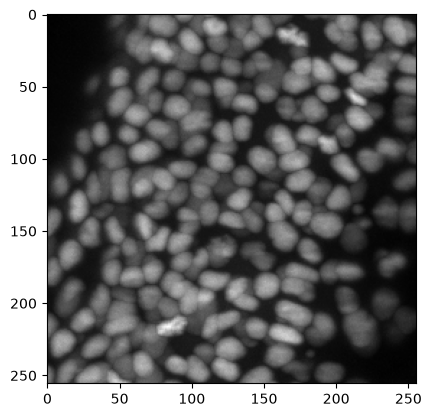

In [146]:
t = 75
img = np.asarray(vol[t]).max(0)
plt.imshow(img, cmap="gray")
plt.show()

In [147]:
g = zarr.open(
    "/hpcstor6/scratch01/a/a.kanamarlapudi001/cell_tracking/biohub-cell-tracking-during-development/train/44b6_0113de3b.geff",
    mode="r",
)


In [148]:
print(g.tree())

/
├── edges
│   ├── ids (50, 2) uint64
│   └── props
└── nodes
    ├── ids (52,) uint64
    └── props
        ├── t
        │   └── values (52,) int64
        ├── x
        │   └── values (52,) int64
        ├── y
        │   └── values (52,) int64
        └── z
            └── values (52,) int64



In [149]:
nodes = pd.DataFrame({
    "id": np.asarray(g["nodes/ids"]),
    "t": np.asarray(g["nodes/props/t/values"]),
    "z": np.asarray(g["nodes/props/z/values"]),
    "y": np.asarray(g["nodes/props/y/values"]),
    "x": np.asarray(g["nodes/props/x/values"]),
})
edges = pd.DataFrame(np.asarray(g["edges/ids"]), columns=["source", "target"])


In [150]:
nodes


,id,t,z,y,x
0,11000000075,0,63,222,249
1,12000000075,1,63,227,251
2,13000000075,2,63,230,253
3,38000000003,27,1,74,73
4,39000000003,28,3,78,75
5,40000000003,29,5,80,77
6,41000000003,30,7,86,78
7,42000000003,31,9,91,77
8,43000000003,32,11,98,81
9,44000000003,33,11,104,78


In [151]:
edges.head()

,source,target
0,11000000075,12000000075
1,12000000075,13000000075
2,38000000003,39000000003
3,39000000003,40000000003
4,40000000003,41000000003


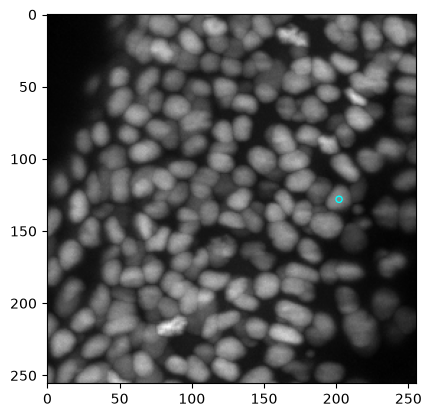

In [152]:
pts = nodes[nodes["t"] == t]
plt.imshow(img, cmap="gray")
plt.scatter(pts["x"], pts["y"], s=20, facecolors="none", edgecolors="cyan")
plt.show()

In [153]:
print((nodes["t"] == t).sum())      # 0 means no overlay dots
print(sorted(nodes["t"].unique()))  # times that DO have labels

1
[np.int64(0), np.int64(1), np.int64(2), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75)]
